In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for high-quality notebook visuals
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load the dataset
df = pd.read_csv('train.csv')

# Display basic structural information
print("--- Dataset Info ---")
df.info()
print("\n--- First 5 Rows ---")
df.head()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# 1. Check for duplicates
print(f"Duplicate rows found: {df.duplicated().sum()}")

# 2. Handle missing data
# Drop 'Cabin' because ~77% of it is missing
df.drop(columns=['Cabin'], inplace=True)

# Impute 'Age' using the median age of passengers within the same ticket class (Pclass)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Impute 'Embarked' with the most common port (the mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop unneeded structural identifiers for EDA
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicate rows found: 0

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


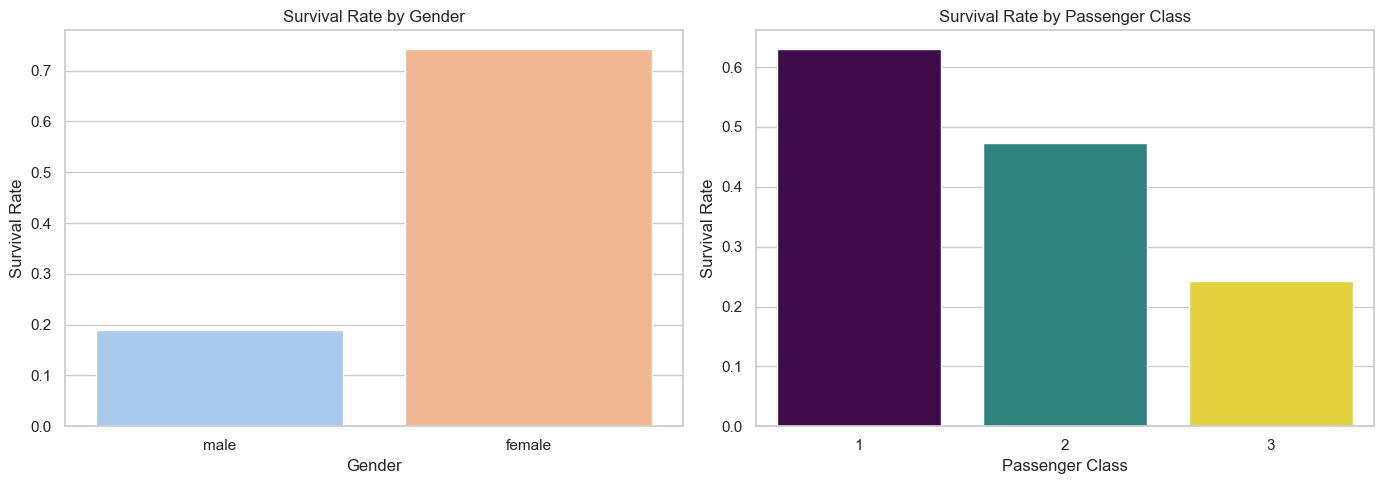

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Survival by Gender
sns.barplot(
    data=df,
    x='Sex',
    y='Survived',
    hue='Sex',
    palette='pastel',
    errorbar=None,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Survival Rate')

# Subplot 2: Survival by Passenger Class
sns.barplot(
    data=df,
    x='Pclass',
    y='Survived',
    hue='Pclass',
    palette='viridis',
    errorbar=None,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

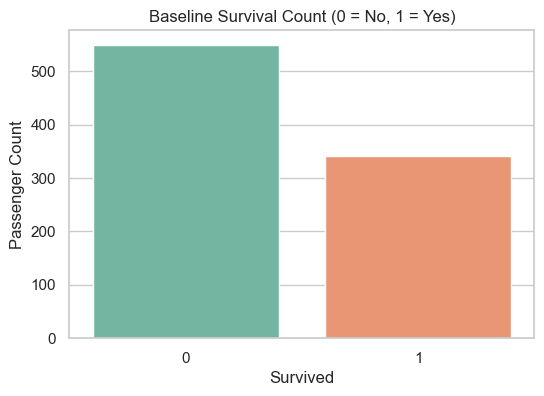

Survival Percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Survived',
    hue='Survived',
    palette='Set2',
    legend=False
)

plt.title("Baseline Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

plt.show()

print("Survival Percentages:")
print(df["Survived"].value_counts(normalize=True).mul(100).round(2))

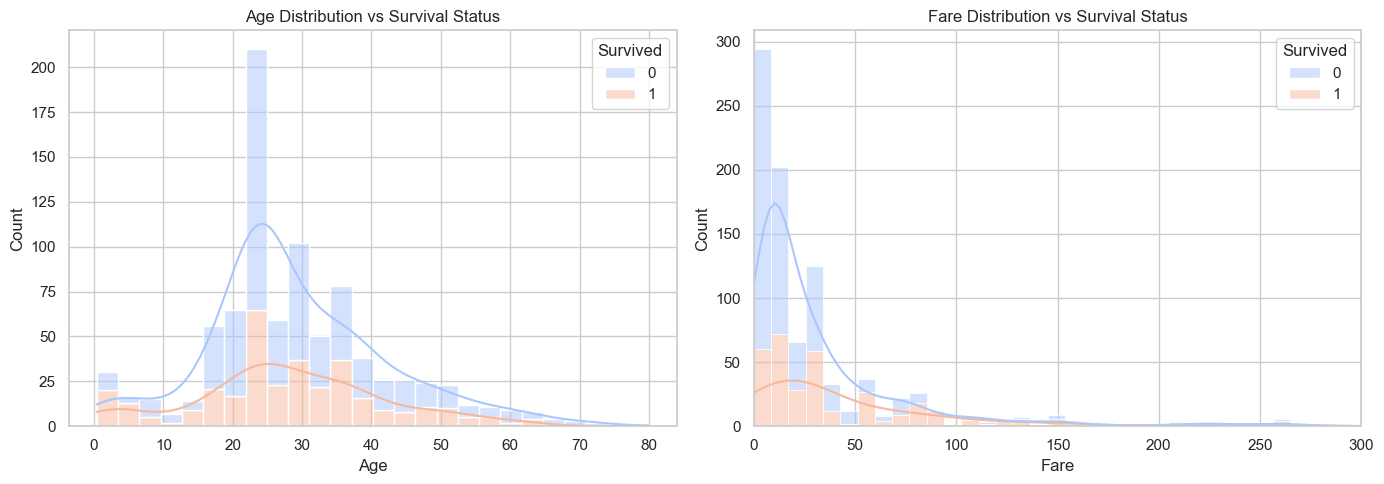

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Age Distribution vs Survival
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack', palette='coolwarm', ax=axes[0])
axes[0].set_title('Age Distribution vs Survival Status')

# Subplot 2: Fare Distribution vs Survival (capped at $300 for visualization clarity)
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, multiple='stack', palette='coolwarm', ax=axes[1])
axes[1].set_title('Fare Distribution vs Survival Status')
axes[1].set_xlim(0, 300) 

plt.tight_layout()
plt.show()

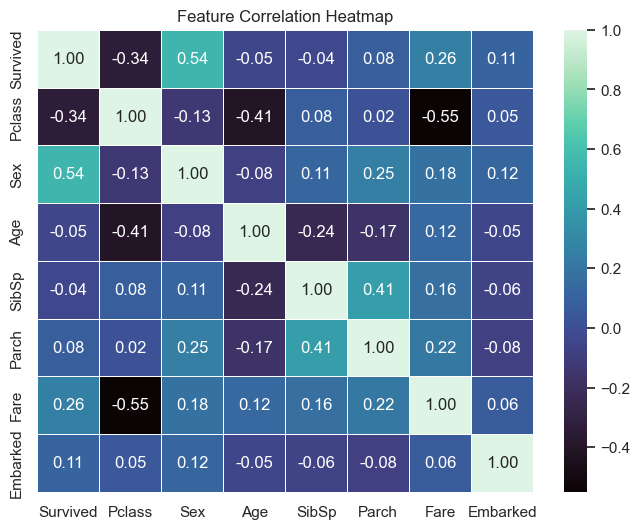

In [6]:
# Convert text categories to temporary numeric values for correlation mapping
df_encoded = df.copy()
df_encoded['Sex'] = df_encoded['Sex'].map({'male': 0, 'female': 1})
df_encoded['Embarked'] = df_encoded['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()